In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
#Load the data
df = pd.read_csv(
    "../data/raw/WHO-COVID-19-global-daily-data.csv"
)

df["Date_reported"] = pd.to_datetime(
    df["Date_reported"]
)

df["year"] = df["Date_reported"].dt.year

print(df.shape)

(556560, 9)


In [6]:
#create nigeria subset
nigeria = df[
    df["Country"] == "Nigeria"
].copy()

nigeria_2020_2021 = nigeria[
    nigeria["year"].isin([2020, 2021])
].copy()

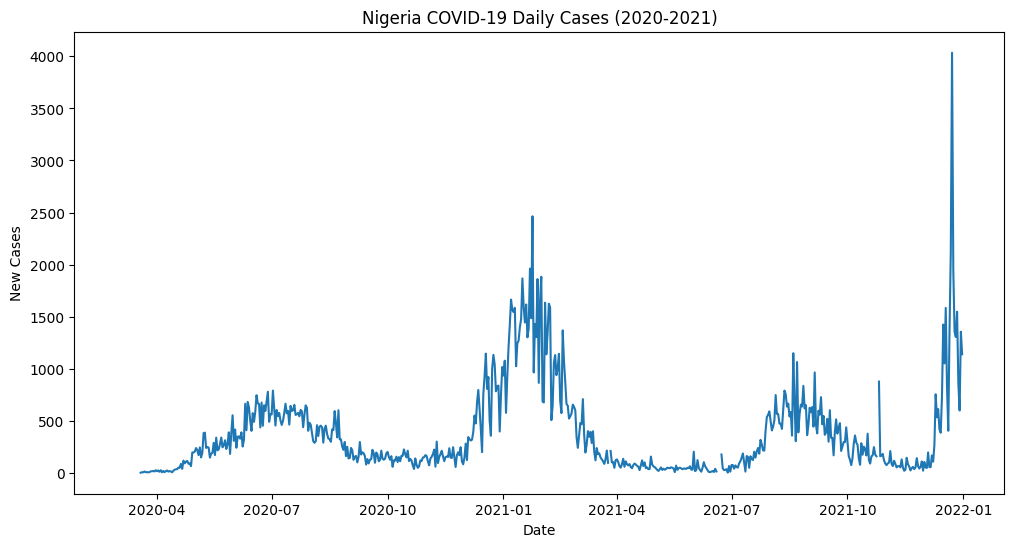

In [7]:
#create a quick epidemic curve
plt.figure(figsize = (12,6))

plt.plot(
    nigeria_2020_2021["Date_reported"],
    nigeria_2020_2021["New_cases"]
)

plt.title(
    "Nigeria COVID-19 Daily Cases (2020-2021)"
)

plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

## Initial Epidemic Curve Observations

- Multiple COVID-19 waves are visible in Nigeria during 2020–2021.
- A moderate wave occurred in mid-2020.
- A larger wave occurred between December 2020 and February 2021.
- Another wave is visible during mid-2021.
- A sharp increase in reported cases occurs in late 2021.
- Further investigation is required before attributing waves to specific variants or public-health events.

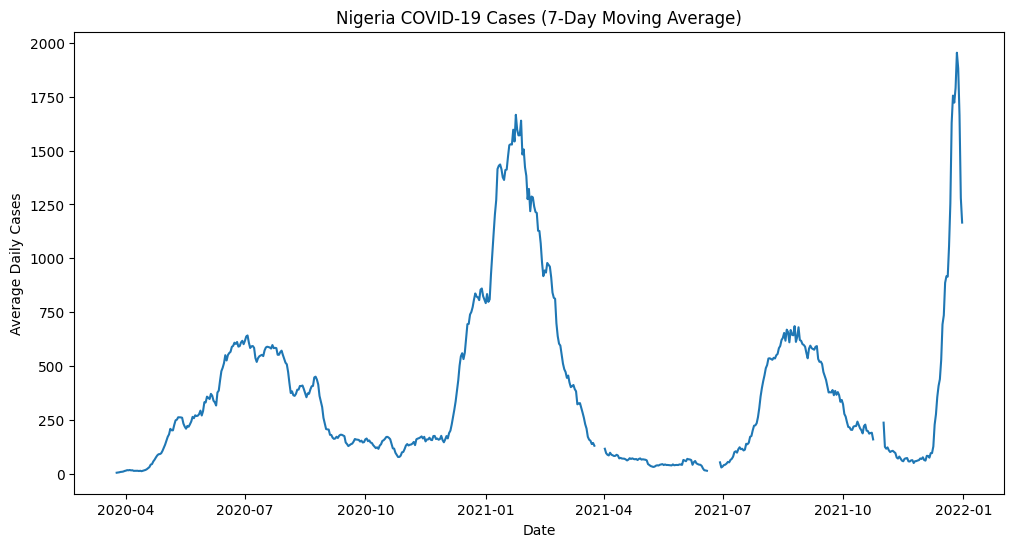

In [8]:
# Smoothing using 7-day moving aveage
nigeria_2020_2021["cases_ma7"] = (
    nigeria_2020_2021["New_cases"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    nigeria_2020_2021["Date_reported"],
    nigeria_2020_2021["cases_ma7"]
)

plt.title(
    "Nigeria COVID-19 Cases (7-Day Moving Average)"
)

plt.xlabel("Date")
plt.ylabel("Average Daily Cases")

plt.show()

## 7-Day Moving Average Observations

- Four major COVID-19 waves are visible during 2020–2021.
- The largest sustained wave occurred around January 2021.
- Another large wave begins in December 2021.
- The moving average reveals epidemic patterns more clearly than raw daily counts.
- Additional contextual information is required before attributing peaks to specific variants or policy changes.

In [10]:
monthly_cases = (
    nigeria_2020_2021
    .groupby(
        pd.Grouper(
            key="Date_reported",
            freq="ME"
        )
    )["New_cases"]
    .sum()
    .reset_index()
)

monthly_cases.head()

,Date_reported,New_cases
0,2020-01-31,0.0
1,2020-02-29,1.0
2,2020-03-31,135.0
3,2020-04-30,1592.0
4,2020-05-31,8127.0


In [11]:
monthly_cases.sort_values(
    "New_cases",
    ascending=False
).head(10)

,Date_reported,New_cases
12,2021-01-31,43981.0
23,2021-12-31,27400.0
13,2021-02-28,24860.0
11,2020-12-31,19164.0
19,2021-08-31,18394.0
6,2020-07-31,17556.0
5,2020-06-30,15278.0
20,2021-09-30,13679.0
7,2020-08-31,11176.0
4,2020-05-31,8127.0


## Monthly Burden Findings

- January 2021 recorded the highest monthly case burden (43,981 cases).
- December 2021 recorded the second highest monthly burden (27,400 cases).
- February 2021 recorded the third highest monthly burden (24,860 cases).
- The January 2021 wave was both visually prominent and quantitatively the largest observed wave during the study period.

In [12]:
monthly_deaths = (
    nigeria_2020_2021
    .groupby(
        pd.Grouper(
            key="Date_reported",
            freq="ME"
        )
    )["New_deaths"]
    .sum()
    .reset_index()
)

monthly_deaths.sort_values(
    "New_deaths",
    ascending=False
).head(10)

,Date_reported,New_deaths
13,2021-02-28,327.0
19,2021-08-31,306.0
6,2020-07-31,305.0
5,2020-06-30,300.0
12,2021-01-31,300.0
20,2021-09-30,247.0
4,2020-05-31,220.0
21,2021-10-31,193.0
14,2021-03-31,151.0
7,2020-08-31,135.0


## Cases vs Deaths Findings

- January 2021 recorded the highest monthly case burden (43,981 cases).
- February 2021 recorded the highest monthly mortality burden (327 deaths).
- Peak mortality occurred after peak incidence.
- This pattern is consistent with a possible lag between infection and death.
- Further investigation would be required to quantify the lag.

In [13]:
monthly_compare = (
    monthly_cases
    .merge(
        monthly_deaths,
        on="Date_reported",
        how="inner"
    )
)

monthly_compare["deaths_per_1000_cases"] = (
    monthly_compare["New_deaths"]
    /
    monthly_compare["New_cases"]
) * 1000

monthly_compare.sort_values(
    "deaths_per_1000_cases",
    ascending=False
).head(10)

,Date_reported,New_cases,New_deaths,deaths_per_1000_cases
17,2021-06-30,1228.0,49.0,39.902280
22,2021-11-30,2226.0,81.0,36.388140
3,2020-04-30,1592.0,49.0,30.778894
21,2021-10-31,6403.0,193.0,30.142121
2,2020-03-31,135.0,4.0,29.629630
4,2020-05-31,8127.0,220.0,27.070260
14,2021-03-31,7345.0,151.0,20.558203
8,2020-09-30,4782.0,98.0,20.493517
5,2020-06-30,15278.0,300.0,19.636078
20,2021-09-30,13679.0,247.0,18.056876


In [14]:
monthly_compare = (
    monthly_cases
    .merge(
        monthly_deaths,
        on = "Date_reported",
        how = "inner"
    )
)

monthly_compare.head()

,Date_reported,New_cases,New_deaths
0,2020-01-31,0.0,0.0
1,2020-02-29,1.0,0.0
2,2020-03-31,135.0,4.0
3,2020-04-30,1592.0,49.0
4,2020-05-31,8127.0,220.0


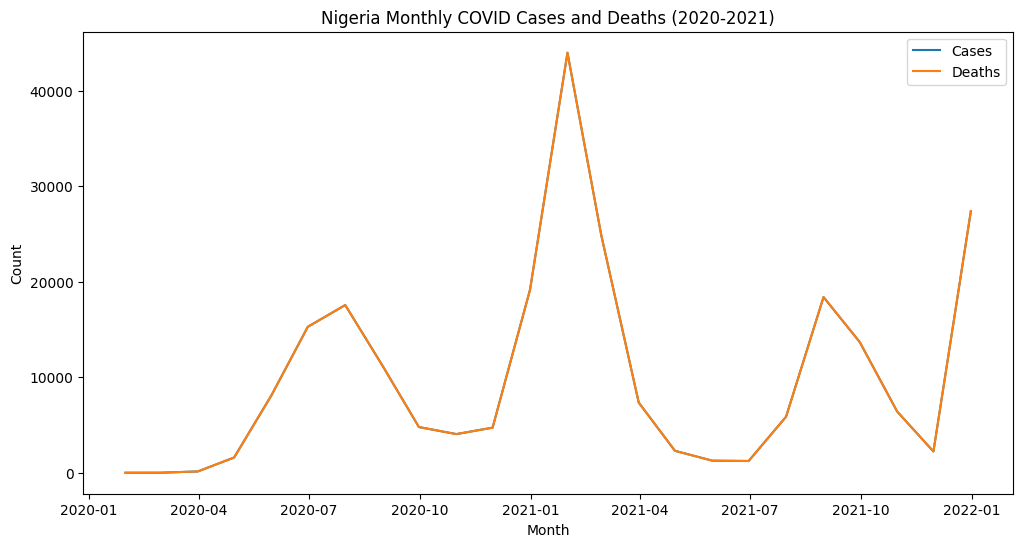

In [16]:
plt.figure(figsize = (12,6))

plt.plot(
    monthly_compare["Date_reported"],
    monthly_compare["New_cases"],
    label = "Cases"
)

plt.plot(
    monthly_compare["Date_reported"],
    monthly_compare["New_cases"],
    label = "Deaths"
)

plt.title(
    "Nigeria Monthly COVID Cases and Deaths (2020-2021)"
)

plt.xlabel("Month")
plt.ylabel("Count")

plt.legend()

plt.show()

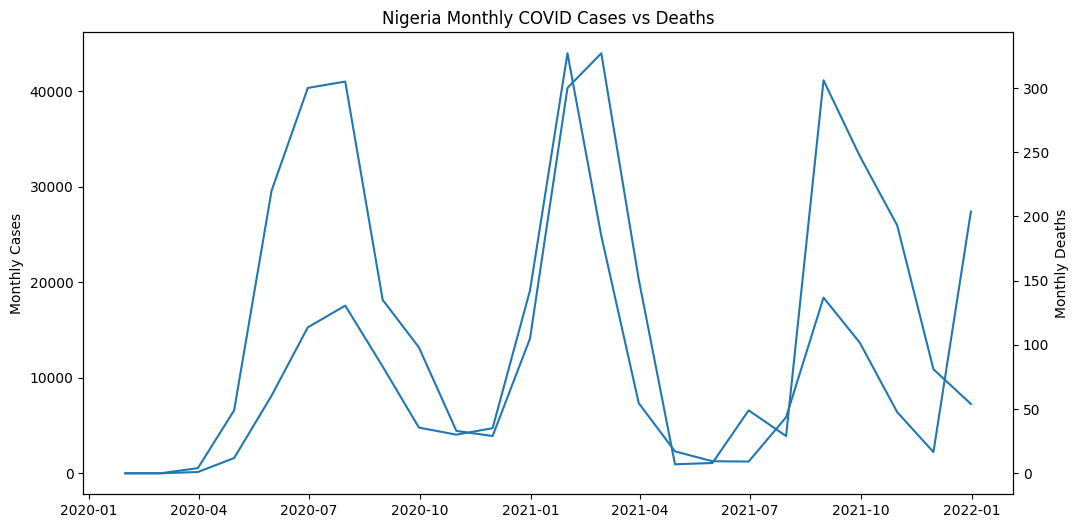

In [17]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(
    monthly_compare["Date_reported"],
    monthly_compare["New_cases"]
)

ax1.set_ylabel(
    "Monthly Cases"
)

ax2 = ax1.twinx()

ax2.plot(
    monthly_compare["Date_reported"],
    monthly_compare["New_deaths"]
)

ax2.set_ylabel(
    "Monthly Deaths"
)

plt.title(
    "Nigeria Monthly COVID Cases vs Deaths"
)

plt.show()

In [23]:
nigeria_daily = (
    nigeria_2020_2021[
        [
            "Date_reported",
            "New_cases",
            "Cumulative_cases",
            "New_deaths",
            "Cumulative_deaths"
        ]
    ]
    .copy()
)

nigeria_daily.head(20)

,Date_reported,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
133,2020-01-04,NaN,0,NaN,0
297,2020-01-05,NaN,0,NaN,0
613,2020-01-06,NaN,0,NaN,0
777,2020-01-07,NaN,0,NaN,0
1093,2020-01-08,NaN,0,NaN,0
1257,2020-01-09,NaN,0,NaN,0
1577,2020-01-10,NaN,0,NaN,0
1737,2020-01-11,NaN,0,NaN,0
2057,2020-01-12,NaN,0,NaN,0
2213,2020-01-13,NaN,0,NaN,0


In [24]:
nigeria_daily[
    nigeria_daily["New_cases"].notna()
].head(10)

,Date_reported,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
13577,2020-02-29,1.0,1,NaN,0
15977,2020-03-10,1.0,2,NaN,0
18057,2020-03-19,1.0,3,NaN,0
18373,2020-03-20,6.0,9,NaN,0
18537,2020-03-21,4.0,13,NaN,0
18853,2020-03-22,13.0,26,NaN,0
19017,2020-03-23,6.0,32,3.0,3
19333,2020-03-24,7.0,39,NaN,3
19489,2020-03-25,4.0,43,NaN,3
19817,2020-03-26,7.0,50,NaN,3


In [25]:
nigeria_daily[
    nigeria_daily["New_deaths"].notna()
].head(10)

,Date_reported,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
19017,2020-03-23,6.0,32,3.0,3
20933,2020-03-31,25.0,136,1.0,4
21897,2020-04-04,25.0,209,2.0,6
22217,2020-04-05,5.0,214,1.0,7
22853,2020-04-08,16.0,254,1.0,8
23329,2020-04-10,12.0,288,1.0,9
23809,2020-04-12,13.0,318,3.0,12
24293,2020-04-14,20.0,343,1.0,13
24773,2020-04-16,34.0,407,1.0,14
25097,2020-04-17,35.0,442,1.0,15


In [26]:
nigeria_daily[
    ["New_cases", "New_deaths"]
].isna().sum()

New_cases      78
New_deaths    280
dtype: int64

In [27]:
(
    nigeria_daily[
        ["New_cases", "New_deaths"]
    ]
    .isna()
    .mean()
    * 100
).round(2)

New_cases     10.71
New_deaths    38.46
dtype: float64

In [28]:
nigeria_daily["cases_ma7"] = (
    nigeria_daily["New_cases"]
    .rolling(7)
    .mean()
)

nigeria_daily["deaths_ma7"] = (
    nigeria_daily["New_deaths"]
    .rolling(7)
    .mean()
)

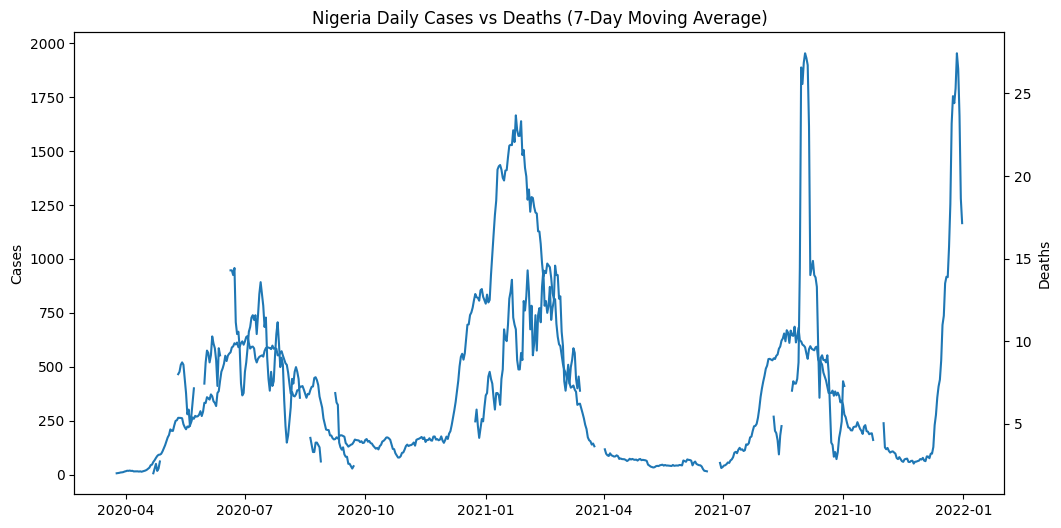

In [29]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(
    nigeria_daily["Date_reported"],
    nigeria_daily["cases_ma7"],
    label="Cases MA7"
)

ax1.set_ylabel("Cases")

ax2 = ax1.twinx()

ax2.plot(
    nigeria_daily["Date_reported"],
    nigeria_daily["deaths_ma7"],
    label="Deaths MA7"
)

ax2.set_ylabel("Deaths")

plt.title(
    "Nigeria Daily Cases vs Deaths (7-Day Moving Average)"
)

plt.show()

In [39]:
# Wave Comparison
wave1 = nigeria_2020_2021[
    (nigeria_2020_2021["Date_reported"] >= "2020-04-01")
    &
    (nigeria_2020_2021["Date_reported"] <= "2020-10-31")
]

wave2 = nigeria_2020_2021[
    (nigeria_2020_2021["Date_reported"] >= "2020-12-01")
    &
    (nigeria_2020_2021["Date_reported"] <= "2021-04-30")
]

wave3 = nigeria_2020_2021[
    (nigeria_2020_2021["Date_reported"] >= "2020-07-01")
    &
    (nigeria_2020_2021["Date_reported"] <= "2020-11-30")
]

In [40]:
wave_summary = pd.DataFrame ({
    "Wave": [
        "wave 1",
        "wave 2",
        "wave 3"
    ],

    "Cases": [
        wave1["New_cases"].sum(),
        wave2["New_cases"].sum(),
        wave3["New_cases"].sum()
    ],

    "Deaths": [
        wave1["New_deaths"].sum(),
        wave2["New_deaths"].sum(),
        wave3["New_deaths"].sum()
    ]

})

wave_summary

,Wave,Cases,Deaths
0,wave 1,62555.0,1140.0
1,wave 2,97643.0,890.0
2,wave 3,42279.0,600.0


In [41]:
wave_summary["deaths_Per_1000_cases"] = (
    wave_summary["Deaths"]
    /
    wave_summary["Cases"]
) * 1000

wave_summary

,Wave,Cases,Deaths,deaths_Per_1000_cases
0,wave 1,62555.0,1140.0,18.223963
1,wave 2,97643.0,890.0,9.114837
2,wave 3,42279.0,600.0,14.191443


## Wave Comparison Findings

- Wave 2 had the highest number of reported cases (97,643).
- Wave 1 had the highest number of reported deaths (1,140).
- Wave 1 had the highest deaths-per-1,000-cases ratio (18.22).
- Wave 2 had the lowest deaths-per-1,000-cases ratio (9.11).
- The relationship between cases and mortality appears to differ across epidemic waves.
- Further investigation would be required to determine whether changes in testing, treatment, immunity, or variants contributed to these differences.